In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

import matplotlib.lines as mlines
from sklearn.cluster import KMeans
from collections import Counter

from scipy.stats import chi2_contingency

In [ ]:
# Dataframe laden und vorbereiten
regions = ['CDR_H1', 'CDR_H2', 'CDR_H3', 'CDR_L1', 'CDR_L2', 'CDR_L3']
ab_ag_annotated = (
    pd.read_csv("data/ab_ag_annotated.tsv", sep="\t", usecols=["pdb"] + ["antigen_name"] + ["antigen_species"] + ["resolution"] + regions)
    .dropna(subset= regions)
    .drop_duplicates(subset = ["pdb"] + regions, keep="first")
    .reset_index(drop=True)
)

ab_ag_annotated = ab_ag_annotated[ab_ag_annotated['resolution'] <= 3.5]

#####liste mit den top antigen_names erstellen
top_antigens = ab_ag_annotated['antigen_name'].value_counts().head(10).index.tolist()
#dataframe filtern sodass nur top 10 antigene drin bleiben
ab_ag_annotated_top = ab_ag_annotated[ab_ag_annotated['antigen_name'].isin(top_antigens)].copy()
#antigen labels definieren sodass nur top 10
antigen_labels = ab_ag_annotated_top["antigen_name"].tolist() #entspricht der spalte "antigen_name" aus ab_ag_annotated_top (aber mit neuen indices!)

#überprüfung was die top 10 sind
print("Top 10 Antigene:")
for ant in top_antigens:
    print(f"-{ant}")
# Liste mit allen proteinogenen Aminosäuren (wird später für die PCA benötigt)
residues = ["A", "C", "D", "E", "F", "G", "H", "I", "K", "L", "M", "N", "P", "Q", "R", "S", "T", "V", "W", "Y"]

Top 10 Antigene:
-spike glycoprotein
-spike protein s1
-guanine nucleotide-binding protein g(i) subunit alpha-1 | guanine nucleotide-binding protein g(i)/g(s)/g(t) subunitbeta-1 
-hemagglutinin
-envelope glycoprotein gp160
-envelope glycoprotein gp120
-neuraminidase
-surface glycoprotein
-hemagglutinin | hemagglutinin
-fusion glycoprotein f0


In [25]:
#PCA nur für AK mit antigen name in den top 10 (pca für alle ist zu finden in annasworksheet)

def residue_percentage(sequence, residues):
    """
    Berechnet den prozentualen Anteil jeder Aminosäure in der gegebenen Sequenz und gibt eine Liste seq_residues zurück,
    die jede Aminosäure als Tupel (residue, percentage) enthält.
    sequence: list, die eine CDR-Sequenz repäsentiert, und deren Einträge aus einem String pro Aminosäure besteht, z.B. ['A', 'R', 'N', ...]
    """
    seq_residues = []
    for residue in residues:
        percentage = sequence.count(residue) / len(sequence)
        seq_residues.append((residue, percentage))
    return seq_residues


def show_feature_space(feature_space, CDR_region, antigen_labels):#zusätzliches Argument für color-coding: antigen
    """
    Visualisiert den Feature-Space der CDR-Sequenzen mittels PCA in 3D.
    feature_space: pd.DataFrame, der die PDB-IDs in einer Spalte "pdb" und die prozentualen Anteile der Aminosäuren in den entsprechenden CDR-Sequenzen
    in je einer Spalte pro Aminosäure enthält.
    """
    X = feature_space.drop(columns=['pdb'])
    coords = PCA(n_components=2).fit_transform(X)
    #hier nochmal die top 10 damit unique antigens auch wirklich nur die top 10 nimmt 
    #####liste mit den top antigen_names erstellen
    top_antigens = ab_ag_annotated['antigen_name'].value_counts().head(10).index.tolist()
    #dataframe filtern sodass nur top 10 antigene drin bleiben
    ab_ag_annotated_top = ab_ag_annotated[ab_ag_annotated['antigen_name'].isin(top_antigens)].copy()
    #antigen labels definieren sodass nur top 10
    antigen_labels = ab_ag_annotated_top["antigen_name"].tolist()

    #### Farbzuordnung vorbereiten

    unique_antigens = sorted(list(set(antigen_labels)))
    color_map = plt.get_cmap('gist_rainbow_r', len(unique_antigens))
    color_dict = {antigen: color_map(i) for i, antigen in enumerate(unique_antigens)}
    colors = [color_dict[a] for a in antigen_labels]
   

    # Plotten der PCA-Koordinaten in 3D
    fig, (ax_scatter, ax_legend) = plt.subplots(2,1,figsize=(10,10), gridspec_kw={'height_ratios': [4,1]})
    ax_scatter.scatter(coords[:, 0], coords[:, 1], c=colors, s=20, alpha=0.7)#zusätzliche Argumente für color-coding: c=color_codes, cmap='tab20', 
    ax_scatter.set_xlabel("PCA 1")
    ax_scatter.set_ylabel("PCA 2")
    ax_scatter.set_title(f"PCA of {CDR_region} Sequences")


    # 2. Legende als eigene Figure
    legend_fig, legend_ax = plt.subplots(figsize=(12, 12))  # Größe anpassen je nach Anzahl Antigene
    legend_ax.axis('off')  # Keine Achsen

    # Erstelle Handles
    handles = [mlines.Line2D([], [], color=color_dict[ant], marker='o', linestyle='None',
                             markersize=8, label=ant)
               for ant in unique_antigens]

    # Erzeuge Legende
    legend = legend_ax.legend(handles=handles, loc='center', ncol=1, fontsize='small')  # ncol=1 → alle untereinander

    legend_fig.tight_layout()
    plt.show()

In [26]:
unique_antigens = sorted(list(set(antigen_labels)))
color_map = plt.get_cmap('gist_rainbow_r', len(unique_antigens))
color_dict = {antigen: color_map(i) for i, antigen in enumerate(unique_antigens)}
colors = [color_dict[a] for a in antigen_labels]

# Schleife über die CDR-Regionen, um den Feature-Space für jede CDR-Sequenz zu erstellen und zu visualisieren:
for CDR_region in ["CDR_H1", "CDR_H2", "CDR_H3", "CDR_L1", "CDR_L2", "CDR_L3"]:
    # pd.dataframe mit den PDB-IDs und CDR-Sequenzen erstellen. Einträge sind keine Listen, sondern Strings, die Listen repräsentieren (aufgrund der .to_csv()-Methode)!
    sequences = ab_ag_annotated_top[["pdb", CDR_region]].copy()
    # CDR-Sequenzen im pd.dataframe sequences von Strings in Listen umwandeln. Die .items() greift auf die Index-Eintrag-Paare des pd.dataframes sequences zu.
    for i, s in sequences[CDR_region].items(): #i= Index, s = String, l= Liste
        l = list(s)
        sequences.at[i, CDR_region] = l
    
    # Leere Matrix für den Feature-Space vorbereiten. Enthält die PDB-IDs, aber noch keine prozentualen Anteile der Aminosäuren.
    feature_space = pd.DataFrame(columns=residues, index=sequences.index)
    feature_space.insert(0, "pdb", ab_ag_annotated_top["pdb"])
    
    # Berechne den prozentualen Anteil jeder Aminosäure in den CDR-Sequenzen und füge sie in den Feature-Space ein.
    rows = [] #um daten vor befüllen des dataframes vorzubereiten damit es nicht so lange dauert
    for i in feature_space.index:
        sequence = sequences.at[i, CDR_region]
        seq_residues = residue_percentage(sequence, residues)
        row = {'pdb': sequences.at[i,'pdb']} #auch für schneller
        for residue, percentage in seq_residues: # Für jedes Tupel (Residue, prozentualer Anteil) in der Liste seq_residues
            feature_space.at[i, residue] = percentage # Füge den prozentualen Anteil des Residues in der CDR-Sequenz in die entsprechende Spalte ein
        rows.append(row)
    #show_feature_space(feature_space, CDR_region, antigen_labels)



#Überprüfung ob alle punkte mit gleichem antigen-name die gleiche farbe haben am bsp influenza a virus
idx_influenzaavirus = [i for i, a in enumerate(antigen_labels) if a == "influenza a virus"]
set([colors[i] for i in idx_influenzaavirus])

#alle farben pro antigen tabellarisch
for ant in set(antigen_labels):
    print(f"{ant}: {color_dict[ant]}")

hemagglutinin | hemagglutinin: (0.0, 1.0, 0.23894862604540001, 1.0)
fusion glycoprotein f0: (0.04227053140096615, 0.0, 1.0, 1.0)
hemagglutinin: (0.0, 1.0, 0.836320191158901, 1.0)
neuraminidase: (0.36036036036036045, 1.0, 0.0, 1.0)
surface glycoprotein: (1.0, 0.0, 0.16, 1.0)
guanine nucleotide-binding protein g(i) subunit alpha-1 | guanine nucleotide-binding protein g(i)/g(s)/g(t) subunitbeta-1 : (0.0, 0.5615942028985507, 1.0, 1.0)
envelope glycoprotein gp160: (0.6461352657004832, 0.0, 1.0, 1.0)
spike glycoprotein: (0.9609609609609602, 1.0, 0.0, 1.0)
envelope glycoprotein gp120: (1.0, 0.0, 0.75, 1.0)
spike protein s1: (1.0, 0.43843843843843866, 0.0, 1.0)


c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

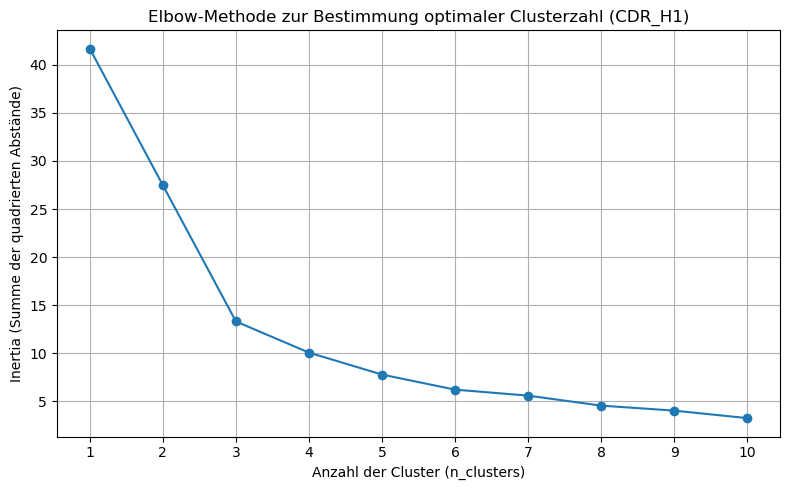

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

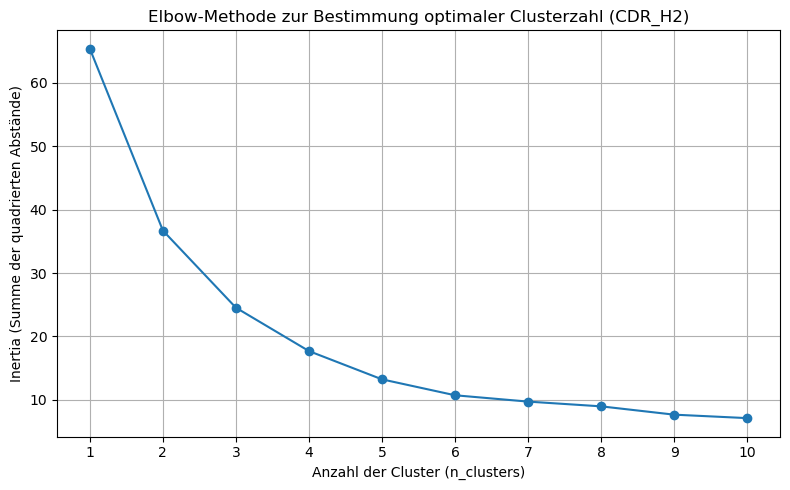

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

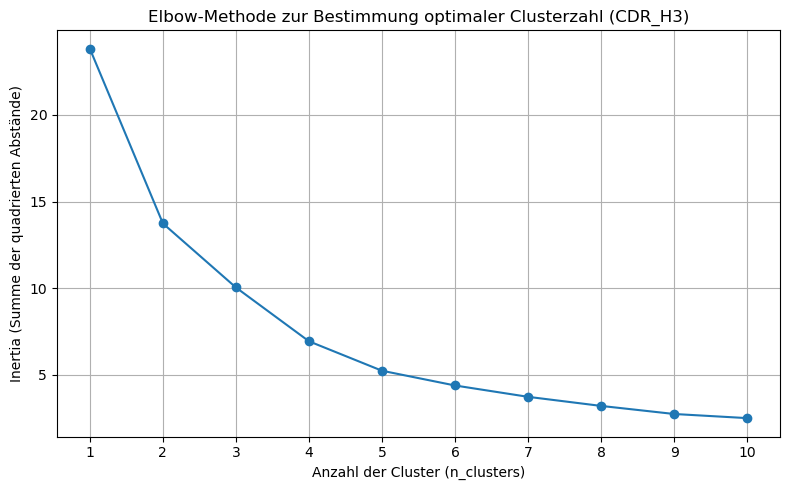

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

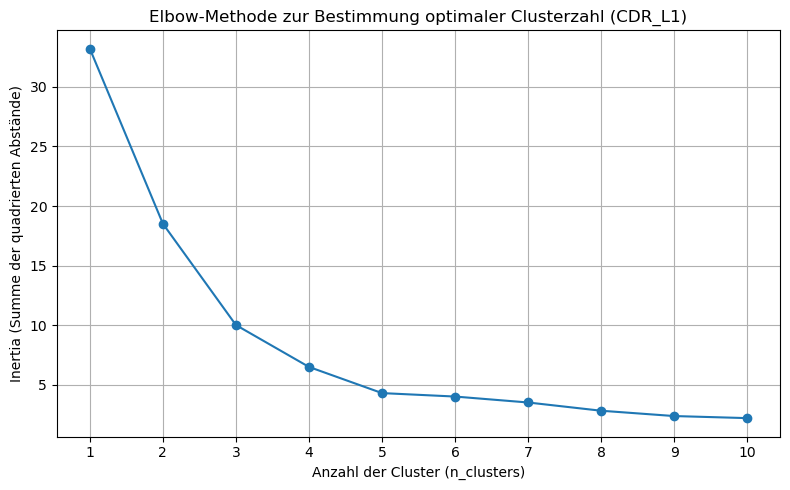

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

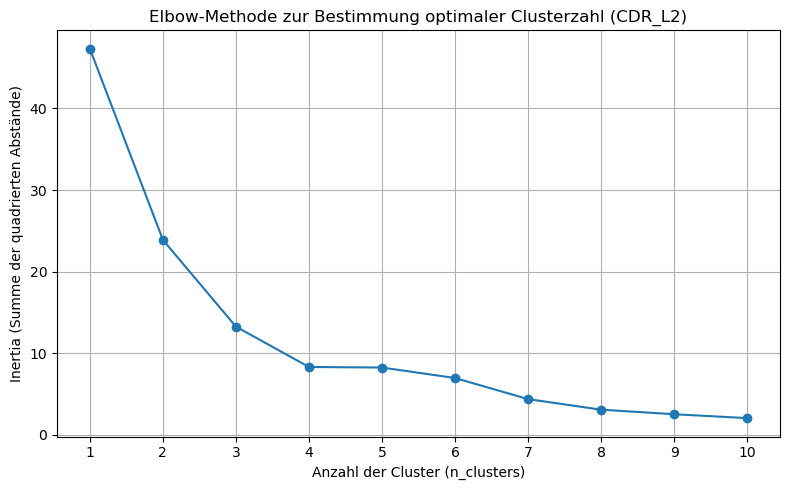

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

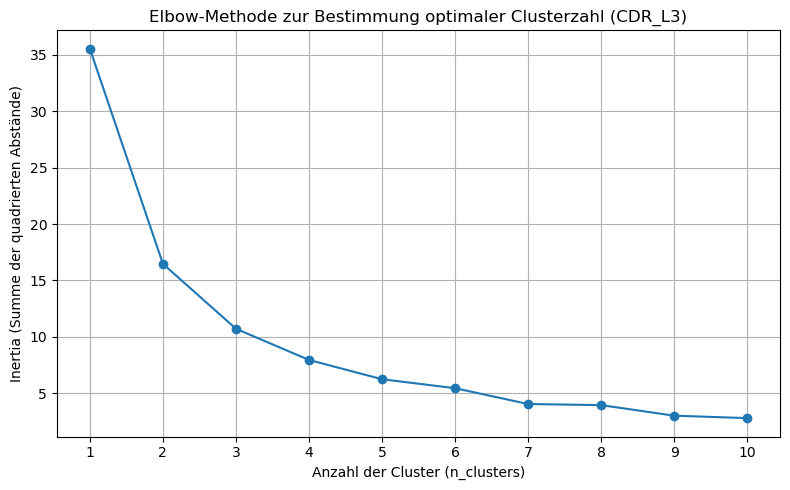

In [27]:
#elbow method 
#der erste teil ist wieder nur wdh weil der sonst die variabeln nicht findet

for CDR_region in ["CDR_H1", "CDR_H2", "CDR_H3", "CDR_L1", "CDR_L2", "CDR_L3"]:
    # pd.dataframe mit den PDB-IDs und CDR-Sequenzen erstellen. Einträge sind keine Listen, sondern Strings, die Listen repräsentieren (aufgrund der .to_csv()-Methode)!
    sequences = ab_ag_annotated_top[["pdb", CDR_region]].copy()
    # CDR-Sequenzen im pd.dataframe sequences von Strings in Listen umwandeln. Die .items() greift auf die Index-Eintrag-Paare des pd.dataframes sequences zu.
    for i, s in sequences[CDR_region].items(): #i= Index, s = String, l= Liste
        l = list(s)
        sequences.at[i, CDR_region] = l

    # Leere Matrix für den Feature-Space vorbereiten. Enthält die PDB-IDs, aber noch keine prozentualen Anteile der Aminosäuren.
    feature_space = pd.DataFrame(columns=residues, index=sequences.index)
    feature_space.insert(0, "pdb", ab_ag_annotated_top["pdb"])
    
    # Berechne den prozentualen Anteil jeder Aminosäure in den CDR-Sequenzen und füge sie in den Feature-Space ein.
    rows = [] #um daten vor befüllen des dataframes vorzubereiten damit es nicht so lange dauert
    for i in feature_space.index:
        sequence = sequences.at[i, CDR_region]
        seq_residues = residue_percentage(sequence, residues)
        row = {'pdb': sequences.at[i,'pdb']} #auch für schneller
        for residue, percentage in seq_residues: # Für jedes Tupel (Residue, prozentualer Anteil) in der Liste seq_residues
            feature_space.at[i, residue] = percentage # Füge den prozentualen Anteil des Residues in der CDR-Sequenz in die entsprechende Spalte ein
        rows.append(row)

    #berücksichtigt nur top 10 aufgrund wie feature space definiert wurde
    X = feature_space.drop(columns=["pdb"])
    coords = PCA(n_components=2).fit_transform(X)

    #elbow method
    #inertia => Summe der quadrierten Abstände der Punkte zum jeweiligen Cluster-Zentrum => je kleiner, desto besser

    # Range of cluster numbers to try
    cluster_range = range(1, 11)  # Teste 1-10 Cluster

    # Hier Inertia-Werte speichern, [] für liste
    inertia_values = []

    # Berechne KMeans für jede Cluster-Anzahl
    for n_clusters in cluster_range:
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        kmeans.fit(coords)  # fit passt daten an modell an => kmeans bekommt daten (coords der antikörper punkte) und initialisiert Cluster Zentren und macht dann iterative optimierung 
        # also weist punkte dem nächsten cluster zentrum zu, bei den gebildeten cluster wenn neue zentren berechnet und die punkte werden neu zugeordnet
        inertia_values.append(kmeans.inertia_)

    # Plot der Elbow-Kurve
    plt.figure(figsize=(8, 5))
    plt.plot(cluster_range, inertia_values, marker='o')
    plt.xlabel('Anzahl der Cluster (n_clusters)')
    plt.ylabel('Inertia (Summe der quadrierten Abstände)')
    plt.title(f'Elbow-Methode zur Bestimmung optimaler Clusterzahl ({CDR_region})')
    plt.xticks(cluster_range) #x achse werden dann anzhal cluster gezeigt
    plt.grid(True) #gitternetzlinien im plot
    plt.tight_layout()
    plt.show()


c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


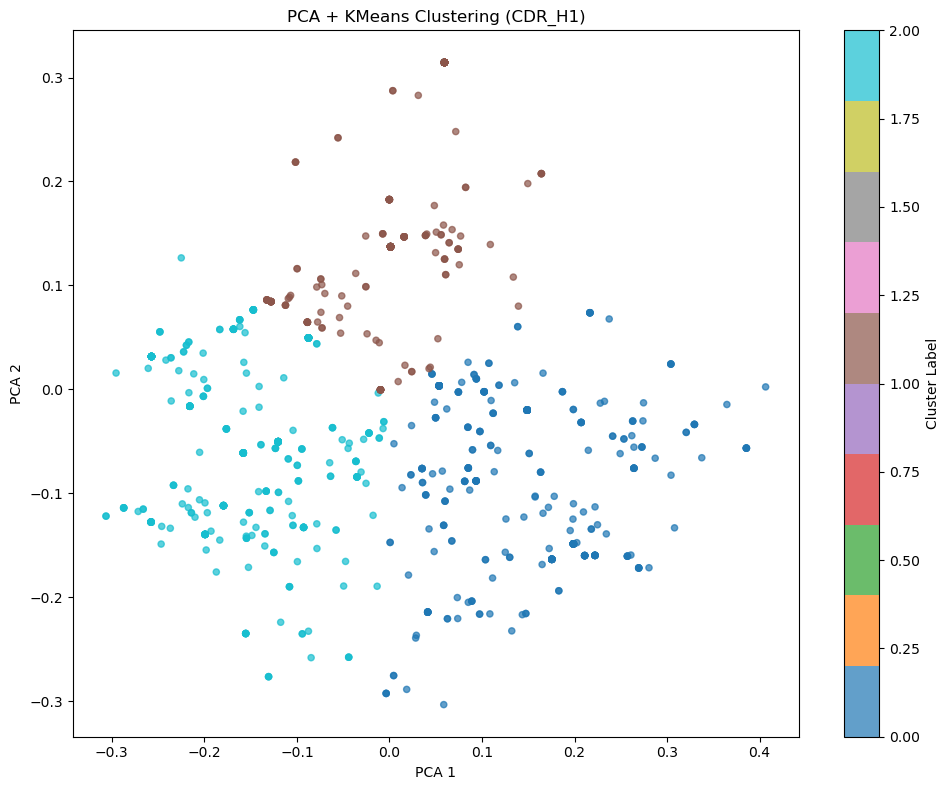


 Antigen Häufigkeiten pro Cluster für CDR_H1 

Cluster 0:
  spike protein s1: 125x
  spike glycoprotein: 116x
  hemagglutinin: 37x
  neuraminidase: 19x
  surface glycoprotein: 18x
  envelope glycoprotein gp160: 17x
  envelope glycoprotein gp120: 13x
  hemagglutinin | hemagglutinin: 6x
  fusion glycoprotein f0: 3x

Cluster 1:
  spike glycoprotein: 89x
  spike protein s1: 87x
  guanine nucleotide-binding protein g(i) subunit alpha-1 | guanine nucleotide-binding protein g(i)/g(s)/g(t) subunitbeta-1 : 77x
  hemagglutinin: 12x
  fusion glycoprotein f0: 8x
  surface glycoprotein: 8x
  hemagglutinin | hemagglutinin: 7x
  neuraminidase: 5x
  envelope glycoprotein gp120: 2x
  envelope glycoprotein gp160: 1x

Cluster 2:
  spike glycoprotein: 142x
  spike protein s1: 106x
  envelope glycoprotein gp160: 35x
  envelope glycoprotein gp120: 25x
  hemagglutinin: 15x
  neuraminidase: 11x
  hemagglutinin | hemagglutinin: 11x
  fusion glycoprotein f0: 10x
  surface glycoprotein: 7x


c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


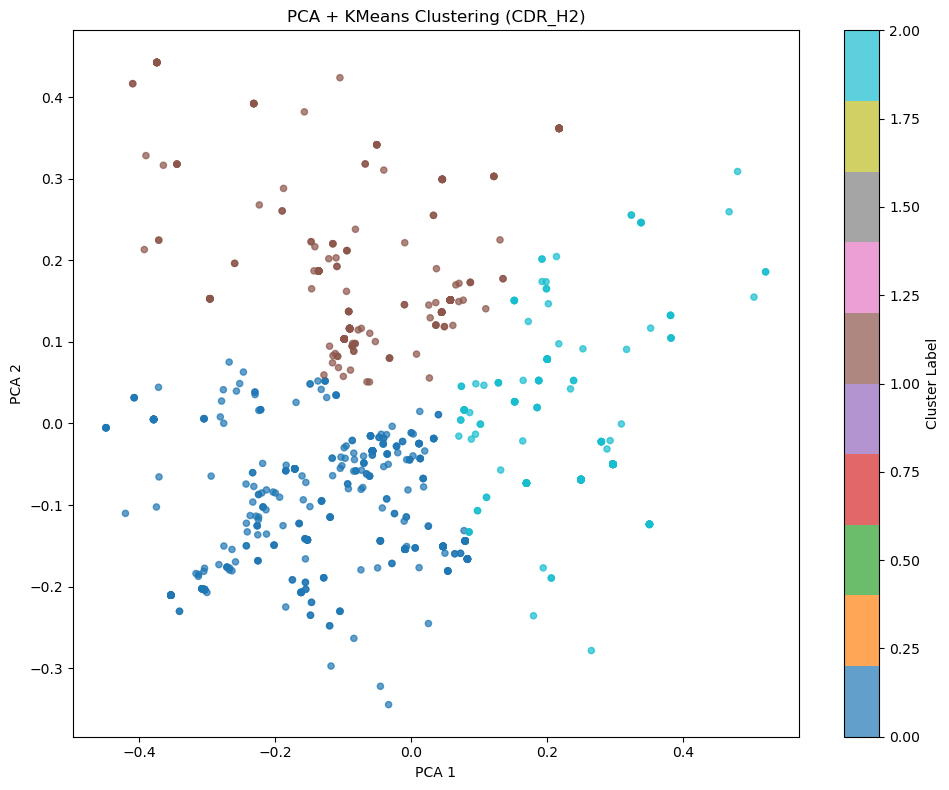


 Antigen Häufigkeiten pro Cluster für CDR_H2 

Cluster 0:
  spike glycoprotein: 183x
  spike protein s1: 133x
  hemagglutinin: 32x
  envelope glycoprotein gp120: 27x
  neuraminidase: 26x
  envelope glycoprotein gp160: 21x
  surface glycoprotein: 16x
  hemagglutinin | hemagglutinin: 14x
  fusion glycoprotein f0: 7x

Cluster 1:
  spike glycoprotein: 94x
  spike protein s1: 83x
  envelope glycoprotein gp160: 32x
  hemagglutinin: 15x
  envelope glycoprotein gp120: 13x
  surface glycoprotein: 11x
  neuraminidase: 6x
  fusion glycoprotein f0: 6x
  hemagglutinin | hemagglutinin: 5x

Cluster 2:
  spike protein s1: 102x
  guanine nucleotide-binding protein g(i) subunit alpha-1 | guanine nucleotide-binding protein g(i)/g(s)/g(t) subunitbeta-1 : 77x
  spike glycoprotein: 70x
  hemagglutinin: 17x
  fusion glycoprotein f0: 8x
  surface glycoprotein: 6x
  hemagglutinin | hemagglutinin: 5x
  neuraminidase: 3x


c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


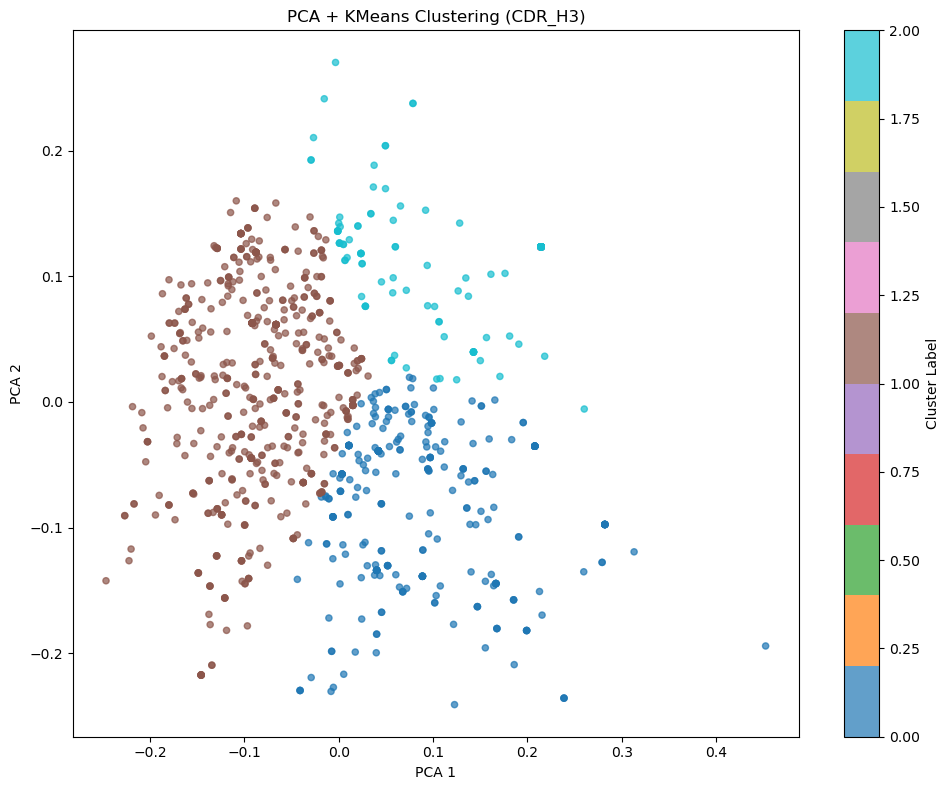


 Antigen Häufigkeiten pro Cluster für CDR_H3 

Cluster 0:
  spike glycoprotein: 110x
  spike protein s1: 109x
  envelope glycoprotein gp160: 23x
  hemagglutinin: 22x
  surface glycoprotein: 12x
  envelope glycoprotein gp120: 8x
  neuraminidase: 3x
  fusion glycoprotein f0: 3x
  hemagglutinin | hemagglutinin: 2x

Cluster 1:
  spike glycoprotein: 197x
  spike protein s1: 188x
  hemagglutinin: 40x
  envelope glycoprotein gp120: 31x
  envelope glycoprotein gp160: 30x
  neuraminidase: 25x
  hemagglutinin | hemagglutinin: 18x
  surface glycoprotein: 18x
  fusion glycoprotein f0: 12x

Cluster 2:
  guanine nucleotide-binding protein g(i) subunit alpha-1 | guanine nucleotide-binding protein g(i)/g(s)/g(t) subunitbeta-1 : 77x
  spike glycoprotein: 40x
  spike protein s1: 21x
  neuraminidase: 7x
  fusion glycoprotein f0: 6x
  hemagglutinin | hemagglutinin: 4x
  surface glycoprotein: 3x
  hemagglutinin: 2x
  envelope glycoprotein gp120: 1x


c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


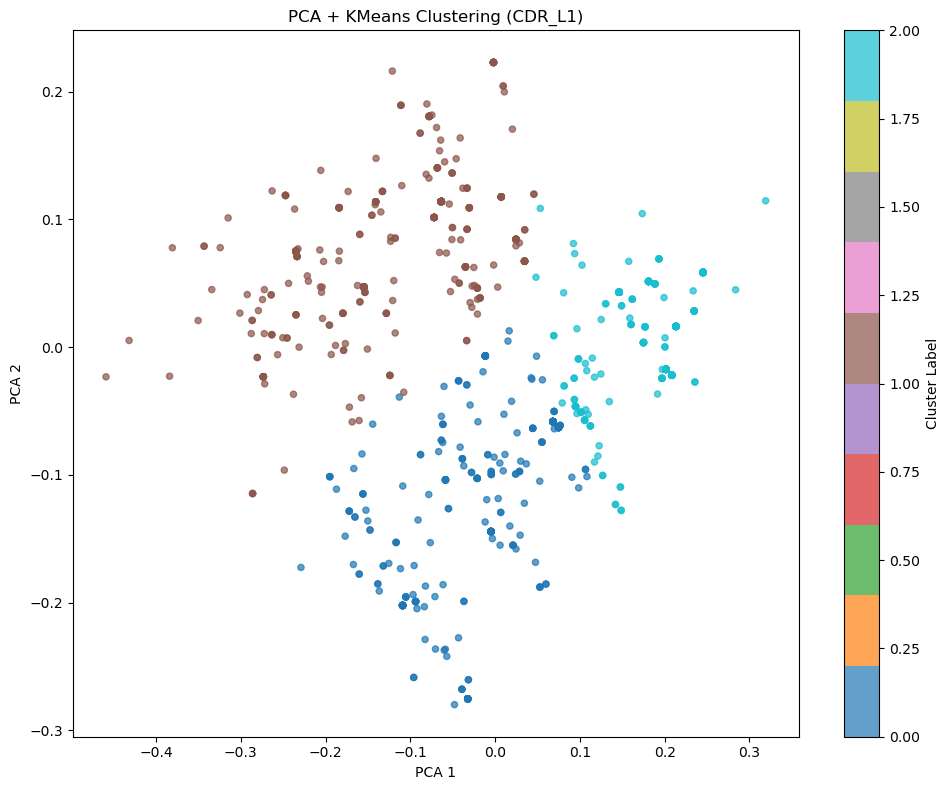


 Antigen Häufigkeiten pro Cluster für CDR_L1 

Cluster 0:
  spike glycoprotein: 109x
  spike protein s1: 96x
  envelope glycoprotein gp160: 27x
  hemagglutinin: 24x
  envelope glycoprotein gp120: 17x
  surface glycoprotein: 12x
  hemagglutinin | hemagglutinin: 9x
  neuraminidase: 8x
  fusion glycoprotein f0: 8x

Cluster 1:
  spike glycoprotein: 126x
  spike protein s1: 109x
  guanine nucleotide-binding protein g(i) subunit alpha-1 | guanine nucleotide-binding protein g(i)/g(s)/g(t) subunitbeta-1 : 77x
  hemagglutinin: 27x
  envelope glycoprotein gp160: 23x
  fusion glycoprotein f0: 13x
  neuraminidase: 10x
  envelope glycoprotein gp120: 8x
  hemagglutinin | hemagglutinin: 8x
  surface glycoprotein: 6x

Cluster 2:
  spike protein s1: 113x
  spike glycoprotein: 112x
  neuraminidase: 17x
  surface glycoprotein: 15x
  envelope glycoprotein gp120: 15x
  hemagglutinin: 13x
  hemagglutinin | hemagglutinin: 7x
  envelope glycoprotein gp160: 3x


c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


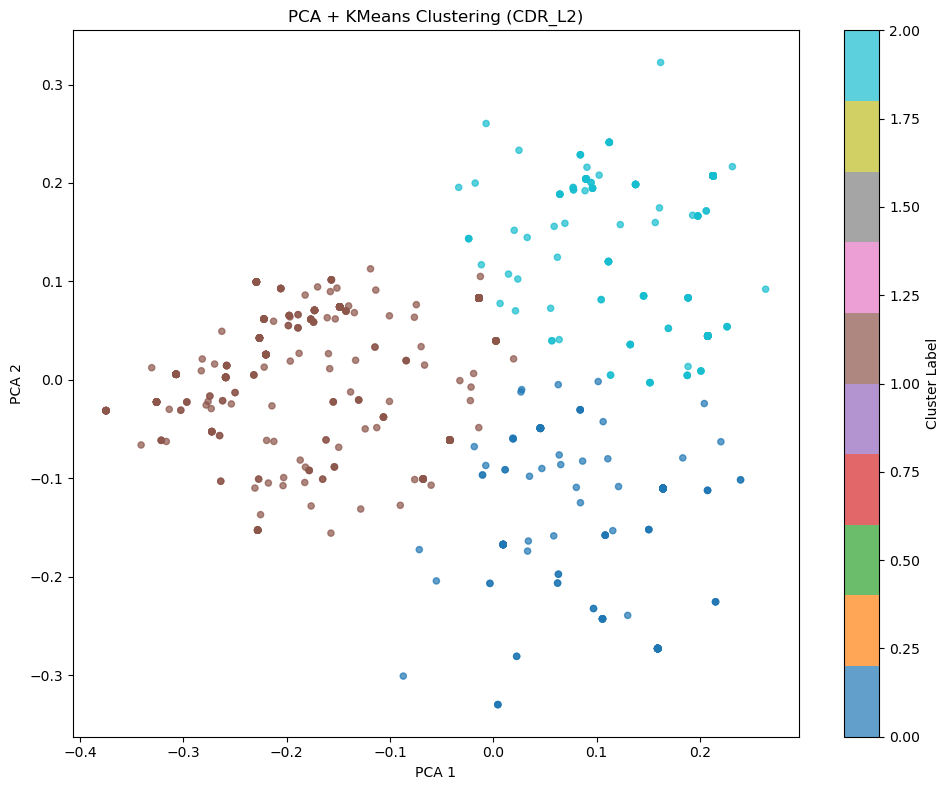


 Antigen Häufigkeiten pro Cluster für CDR_L2 

Cluster 0:
  spike glycoprotein: 107x
  spike protein s1: 92x
  envelope glycoprotein gp120: 20x
  surface glycoprotein: 16x
  neuraminidase: 14x
  envelope glycoprotein gp160: 14x
  hemagglutinin: 11x
  hemagglutinin | hemagglutinin: 6x
  fusion glycoprotein f0: 3x

Cluster 1:
  spike glycoprotein: 147x
  spike protein s1: 121x
  guanine nucleotide-binding protein g(i) subunit alpha-1 | guanine nucleotide-binding protein g(i)/g(s)/g(t) subunitbeta-1 : 77x
  envelope glycoprotein gp160: 37x
  hemagglutinin: 36x
  envelope glycoprotein gp120: 20x
  fusion glycoprotein f0: 15x
  neuraminidase: 10x
  hemagglutinin | hemagglutinin: 8x
  surface glycoprotein: 5x

Cluster 2:
  spike protein s1: 105x
  spike glycoprotein: 93x
  hemagglutinin: 17x
  surface glycoprotein: 12x
  neuraminidase: 11x
  hemagglutinin | hemagglutinin: 10x
  fusion glycoprotein f0: 3x
  envelope glycoprotein gp160: 2x


c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


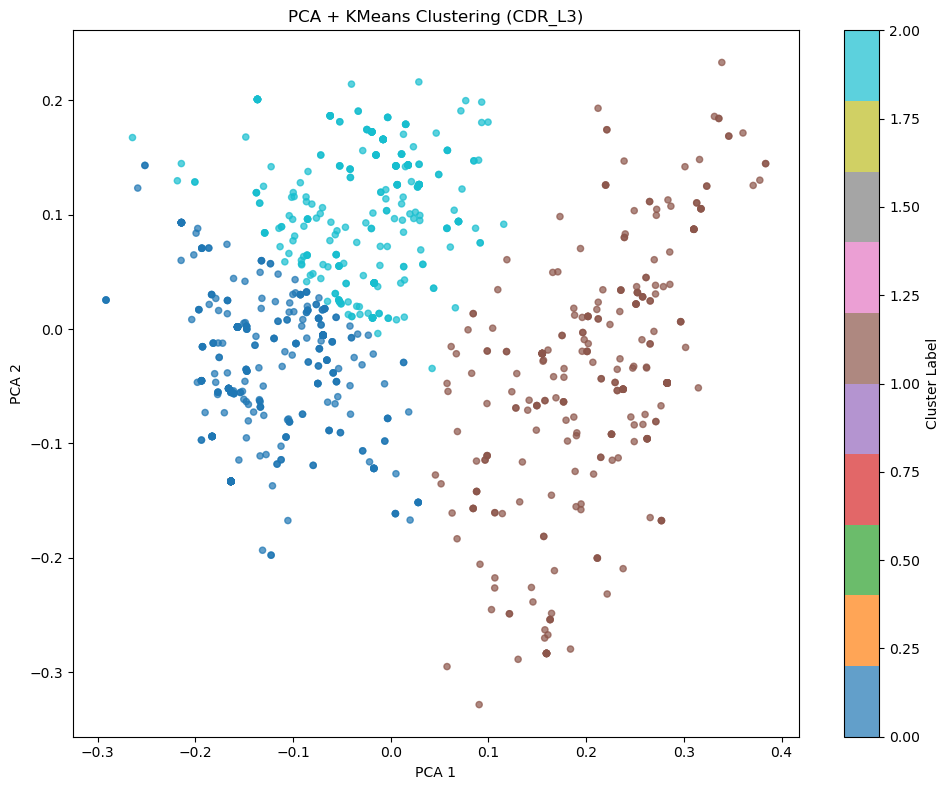


 Antigen Häufigkeiten pro Cluster für CDR_L3 

Cluster 0:
  spike glycoprotein: 133x
  spike protein s1: 108x
  guanine nucleotide-binding protein g(i) subunit alpha-1 | guanine nucleotide-binding protein g(i)/g(s)/g(t) subunitbeta-1 : 77x
  hemagglutinin: 28x
  envelope glycoprotein gp120: 22x
  neuraminidase: 15x
  envelope glycoprotein gp160: 14x
  surface glycoprotein: 12x
  hemagglutinin | hemagglutinin: 8x
  fusion glycoprotein f0: 8x

Cluster 1:
  spike glycoprotein: 100x
  spike protein s1: 87x
  envelope glycoprotein gp160: 36x
  hemagglutinin: 22x
  envelope glycoprotein gp120: 17x
  fusion glycoprotein f0: 12x
  neuraminidase: 9x
  hemagglutinin | hemagglutinin: 6x
  surface glycoprotein: 4x

Cluster 2:
  spike protein s1: 123x
  spike glycoprotein: 114x
  surface glycoprotein: 17x
  hemagglutinin: 14x
  neuraminidase: 11x
  hemagglutinin | hemagglutinin: 10x
  envelope glycoprotein gp160: 3x
  fusion glycoprotein f0: 1x
  envelope glycoprotein gp120: 1x


In [28]:
# Clustering auf basis der PCA
#kmeans mit 3 => laut elbow method am sinnvollsten

 # Schleife über die CDR-Regionen, um den Feature-Space für jede CDR-Sequenz zu erstellen:
for CDR_region in ["CDR_H1", "CDR_H2", "CDR_H3", "CDR_L1", "CDR_L2", "CDR_L3"]:
    # pd.dataframe mit den PDB-IDs und CDR-Sequenzen erstellen. Einträge sind keine Listen, sondern Strings, die Listen repräsentieren (aufgrund der .to_csv()-Methode)!
    sequences = ab_ag_annotated_top[["pdb", CDR_region]].copy()
    # CDR-Sequenzen im pd.dataframe sequences von Strings in Listen umwandeln. Die .items() greift auf die Index-Eintrag-Paare des pd.dataframes sequences zu.
    for i, s in sequences[CDR_region].items(): #i= Index, s = String, l= Liste
        l = list(s)
        sequences.at[i, CDR_region] = l
    
    # Leere Matrix für den Feature-Space vorbereiten. Enthält die PDB-IDs, aber noch keine prozentualen Anteile der Aminosäuren.
    feature_space = pd.DataFrame(columns=residues, index=sequences.index)
    feature_space.insert(0, "pdb", ab_ag_annotated_top["pdb"])
    
    # Berechne den prozentualen Anteil jeder Aminosäure in den CDR-Sequenzen und füge sie in den Feature-Space ein.
    rows = [] #um daten vor befüllen des dataframes vorzubereiten damit es nicht so lange dauert
    for i in feature_space.index:
        sequence = sequences.at[i, CDR_region]
        seq_residues = residue_percentage(sequence,residues)
        row = {'pdb': sequences.at[i,'pdb']} #auch für schneller
        for residue, percentage in seq_residues: # Für jedes Tupel (Residue, prozentualer Anteil) in der Liste seq_residues
            feature_space.at[i, residue] = percentage # Füge den prozentualen Anteil des Residues in der CDR-Sequenz in die entsprechende Spalte ein
        rows.append(row)

    #berücksichtigt nur top 10 aufgrund wie feature space definiert wurde
    X = feature_space.drop(columns=["pdb"])
    coords = PCA(n_components=2).fit_transform(X)

    # n_clusters frei wählbar
    kmeans = KMeans(n_clusters=3, random_state=42) #random state wichtig damit auch bei jeden durchlauf gleiche cluster entstehen
    cluster_labels = kmeans.fit_predict(coords) #fit predict führt clustering im 2d pca space durch

    # Plot => Cluster einfärben
    plt.figure(figsize=(10, 8))
    plt.scatter(coords[:, 0], coords[:, 1], c=cluster_labels, cmap='tab10', s=20, alpha=0.7) #c=cöuster labels färbt die punkte nach cluster; tab10 => 10 farben, alpha => tranparenz damit überlappungen sichtbar, s => punktgröße
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title(f"PCA + KMeans Clustering ({CDR_region})")
    plt.colorbar(label='Cluster Label')
    plt.tight_layout()
    plt.show()

    #antigen names häufigkeiten in den clustern

    # Erzeuge Mapping: cluster_label → liste von antigen names
    # Dictionary ({} => speichert key => value paare) bauen, in dem für jedes Cluster die Liste der zugehörigen Antigen-Namen gespeichert wird
    cluster_antigen_mapping = {}

    # Gehe alle Punkte durch (alle Antikörper im PCA/Feature-Space)
    # → zip(cluster_labels, antigen_labels) gibt für jeden Punkt: cluster_label: die Cluster-Nummer (z.B. 0, 1, 2, ...) & antigen_name: der Antigen-Name dieses Antikörpers
    for cluster_label, antigen_name in zip(cluster_labels, antigen_labels):

        # Wenn dieses Cluster-Label noch nicht im Dictionary ist => leeres Array initialisieren
        if cluster_label not in cluster_antigen_mapping:
            cluster_antigen_mapping[cluster_label] = []

        # Füge den Antigen-Namen zur Liste für dieses Cluster hinzu
        cluster_antigen_mapping[cluster_label].append(antigen_name)

    #jetzt haben wir für jedes cluster eine liste mit den vorkommenden antigen names

    #für häufigkeiten:
    #header damit klar für welche cdr region
    print(f"\n Antigen Häufigkeiten pro Cluster für {CDR_region} ")
    # alle Cluster-Labels sortiert durchgehen
    for cluster_label in sorted(cluster_antigen_mapping.keys()):

        # Drucke Cluster-Header
        print(f"\nCluster {cluster_label}:")

        # wie oft jeder Antigen-Name in diesem Cluster vorkommt
        counter = Counter(cluster_antigen_mapping[cluster_label])

        # Antigen-Namen + Anzahl sortiert nach Häufigkeit aus geben
        for antigen, count in counter.most_common():
            print(f"  {antigen}: {count}x")


In [29]:
#Proportionstest => testen, ob die Antigen-Namen systematisch unterschiedlich auf die Cluster verteilt sind

#nullhypothese (H0): Verteilung der Antigen-Namen auf die Cluster ist zufällig
#H1: Verteilung der Antigen-Namen auf die Cluster ist nicht zufällig

for CDR_region in ["CDR_H1", "CDR_H2", "CDR_H3", "CDR_L1", "CDR_L2", "CDR_L3"]:

    # Kontingenztabelle (Antigen x Cluster) erzeugen

    # automatische Zählung und erstellen von dataframe über crosstab
    contingency_table = pd.crosstab(pd.Series(antigen_labels, name='Antigen'), pd.Series(cluster_labels, name='Cluster'))

    #kontingenztabelle printen
    print(f"\n Kontingenztabelle für {CDR_region}")
    print(contingency_table)

    #chi-quadrat-test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    #chi2=maß für wie stark die beobachteten häufigkeiten von den erwarteten abweichen (je größer, desto größer abweichung)
    #p-Wert=Wahrscheinlichkeit, bei zufälliger Verteilung eine Abweichung mindestens so groß wie chi2 zu beobachten
    #dof=degrees of freedom (#zeilen-1 * #spalten-1)
    #expected=tabelle mit erwarteten häufigkeiten unter nullhypothese

    #print ergebnisse
    print(f"\n Chi-Quadrat-Test Ergebnis für {CDR_region}")
    print(f"Chi2-Wert: {chi2:.4f}") #4f für 4 nachkommSTELLEN
    print(f"p-Wert:    {p:.4e}")  # 4e für exponentielle darstellung mit 4 nachkommastellen
    print(f"Freiheitsgrade: {dof}")

    #print die expected werte zum vergleich
    expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)
    print(f"\nErwartete Häufigkeiten (unter Nullhypothese):")
    print(expected_df.round(2)) #auf 2 nachkommastellen runden

    #die tatsache dass die antigen_name häufigkeiten sehr unterschiedlich sind wird hier automatisch berücksichtigt: 
    #expected-Array wird aus den Randhäufigkeiten berechnet => randhäufigkeiten für antigen =  Summe pro Zeile => wie oft kommt jedes Antigen insgesamt im ganzen Datensatz vor?
    #randhäufigkeiten für cluster=Summe pro Spalte => wie groß ist jedes Cluster insgesamt?

    #wenn p < 0.05 => signifikant also die verteilung unterschiedet sich signifikant von zufall => N0 hypothese muss verworfen werden denn die unterschiede in der verteilung sind nicht durch zufall zu erklären



 Kontingenztabelle für CDR_H1
Cluster                                               0    1    2
Antigen                                                          
envelope glycoprotein gp120                          22   17    1
envelope glycoprotein gp160                          14   36    3
fusion glycoprotein f0                                8   12    1
guanine nucleotide-binding protein g(i) subunit...   77    0    0
hemagglutinin                                        28   22   14
hemagglutinin | hemagglutinin                         8    6   10
neuraminidase                                        15    9   11
spike glycoprotein                                  133  100  114
spike protein s1                                    108   87  123
surface glycoprotein                                 12    4   17

 Chi-Quadrat-Test Ergebnis für CDR_H1
Chi2-Wert: 202.4255
p-Wert:    3.2778e-33
Freiheitsgrade: 18

Erwartete Häufigkeiten (unter Nullhypothese):
Cluster                       